In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from astropy.io import fits
from astropy.coordinates import Angle
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

from astroquery.skyview import SkyView

Load data in pickle format from different grids

In [2]:
with open("df-irregular-grid-E.pkl", "rb") as f:
    df_irr = pickle.load(f)

with open("df-regular-grid-WXY.pkl", "rb") as f:
    df_reg = pickle.load(f)

with open("df-stellar-grid.pkl", "rb") as f:
    df_stel = pickle.load(f)

WCS sky coordinates

In [3]:
c0 = SkyCoord.from_name("Tarantula")
# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]

Combine loaded files in a big data frame

In [4]:
df_irrE  = df_irr['df_irrE']
df_stelA = df_stel['df_stellarA']
df_stelB = df_stel['df_stellarB'] 
df_stelD = df_stel['df_stellarD'] 
df_stelE = df_stel['df_stellarE'] 
df_stelG = df_stel['df_stellarG'] 
df_stelI = df_stel['df_stellarI'] 
df_stelJ = df_stel['df_stellarJ'] 
df_stelK = df_stel['df_stellarK'] 
df_regW = df_reg['df_letterW'] 
df_regX = df_reg['df_letterX'] 
df_regY = df_reg['df_letterY']

In [5]:
dfs_to_combine = {
    "irr": df_irr['df_irrE'],

    "stellarA": df_stel["df_stellarA"],
    "stellarB": df_stel["df_stellarB"],
    "stellarD": df_stel["df_stellarD"],
    "stellarE": df_stel["df_stellarE"],
    "stellarG": df_stel["df_stellarG"],
    "stellarI": df_stel["df_stellarI"],
    "stellarJ": df_stel["df_stellarJ"],
    "stellarK": df_stel["df_stellarK"],

    "letterW": df_reg["df_letterW"],
    "letterX": df_reg["df_letterX"],
    "letterY": df_reg["df_letterY"],
}

In [6]:
df_flames = pd.concat(
    [
        df.assign(sample=name)
        for name, df in dfs_to_combine.items()
    ],
    ignore_index=True
)

In [7]:
df_flames

,filename,object,date_obs,mjd_obs,instrument,telescope,arcfile,prog_id,pro_catg,dpr_catg,dpr_type,dpr_tech,ra_deg,dec_deg,EXPTIME,EXPTIME_round,sample_id,object_group,sample
0,ADP.2019-01-31T23_53_42.052.fits,pos078,2003-12-03T08:13:17.621,52976.342565,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.052.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.550875,-69.148917,1799.9619,1800.0,pos078_ra84.550875_dec-69.148917_exp1800.0,pos_digits,irr
1,ADP.2019-01-31T23_53_42.083.fits,pos011,2003-12-03T08:13:17.621,52976.342565,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.083.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.634750,-69.088028,1799.9619,1800.0,pos011_ra84.63475_dec-69.088028_exp1800.0,pos_digits,irr
2,ADP.2019-01-31T23_53_42.122.fits,pos069,2003-12-03T08:13:17.621,52976.342565,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.122.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.852375,-69.082583,1799.9619,1800.0,pos069_ra84.852375_dec-69.082583_exp1800.0,pos_digits,irr
3,ADP.2019-01-31T23_53_42.163.fits,pos037,2003-12-03T08:13:17.621,52976.342565,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.163.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.610125,-69.163389,1799.9619,1800.0,pos037_ra84.610125_dec-69.163389_exp1800.0,pos_digits,irr
4,ADP.2019-01-31T23_53_42.236.fits,pos093,2003-12-03T08:13:17.621,52976.342565,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.236.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.460167,-69.170167,1799.9619,1800.0,pos093_ra84.460167_dec-69.170167_exp1800.0,pos_digits,irr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,ADP.2019-01-31T23_53_46.806.fits,t45,2003-12-03T05:54:18.706,52976.246050,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:46.806.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.721708,-69.122194,1199.9741,1200.0,t45_ra84.721708_dec-69.122194_exp1200.0,letter_two_digits,letterY
1378,ADP.2019-01-31T23_53_46.840.fits,t48,2003-12-03T05:54:18.706,52976.246050,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:46.840.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.768417,-69.177750,1199.9741,1200.0,t48_ra84.768417_dec-69.17775_exp1200.0,letter_two_digits,letterY
1379,ADP.2019-01-31T23_53_46.930.fits,t56,2003-12-03T05:54:18.706,52976.246050,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:46.930.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.768417,-69.033306,1199.9741,1200.0,t56_ra84.768417_dec-69.033306_exp1200.0,letter_two_digits,letterY
1380,ADP.2019-01-31T23_53_47.091.fits,t54,2003-12-03T05:54:18.706,52976.246050,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:47.091.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.768417,-69.066639,1199.9741,1200.0,t54_ra84.768417_dec-69.066639_exp1200.0,letter_two_digits,letterY


In [8]:
df_flames["object_group"].value_counts()

object_group
digits_only          1000
letter_two_digits     270
pos_digits            112
Name: count, dtype: int64

In [9]:
df_flames["sample"].value_counts()

sample
stellarD    220
stellarI    113
stellarJ    113
irr         112
stellarB    112
stellarA    111
stellarG    111
stellarK    111
stellarE    109
letterW     101
letterX      98
letterY      71
Name: count, dtype: int64

Plots of the different samples

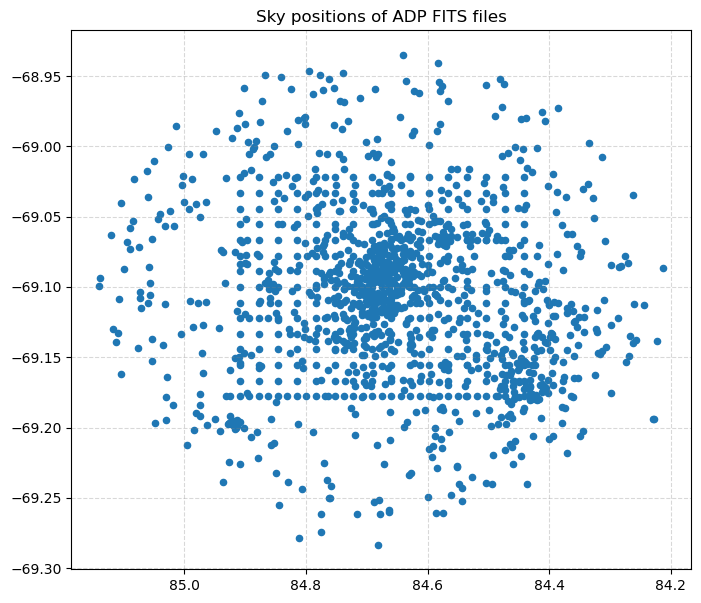

In [10]:

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1)

ax.scatter(
    df_flames["ra_deg"],
    df_flames["dec_deg"],
    s=20,
#    transform=ax.get_transform("world")
)


ax.set_title("Sky positions of ADP FITS files")

#ax.coords[0].set_axislabel("Right Ascension")
#ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")
plt.gca().invert_xaxis()

plt.show()

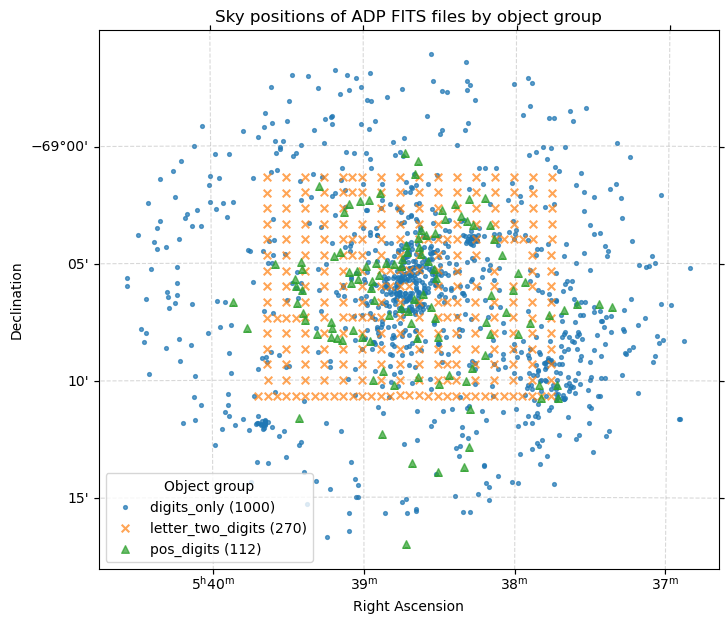

In [11]:
markers = {
    "digits_only": ".",
    "letter_two_digits": "x",
    "pos_digits": "^",
}

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1, projection=wcs)

for group, df_group in df_flames.groupby("object_group"):
    ax.scatter(
        df_group["ra_deg"],
        df_group["dec_deg"],
        s=30,
        marker=markers.get(group, "o"),
        alpha=0.7,
        label=f"{group} ({len(df_group)})",
        transform=ax.get_transform("world")
    )

#for _, row in df_flames.iterrows():
#    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
#    ax.text(
#        row["ra_deg"],
#        row["dec_deg"],
#        label,
#        fontsize=7,
#        transform=ax.get_transform("world")
#    )

ax.set_title("Sky positions of ADP FITS files by object group")

ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")
plt.gca().invert_xaxis()

ax.legend(title="Object group", loc="best")

plt.show()

Astroquery image of 30 Dor

In [12]:
hdu = fits.open("skv_30dor_dss.fits")[0]

image_data = hdu.data
wcs_bg = WCS(hdu.header)

print(image_data.shape)
print(wcs_bg)

(300, 300)
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 84.67665 -69.10093300000001
CRPIX : 150.5 150.5
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -0.00047222219999999997 0.00047222219999999997
NAXIS : 300  300


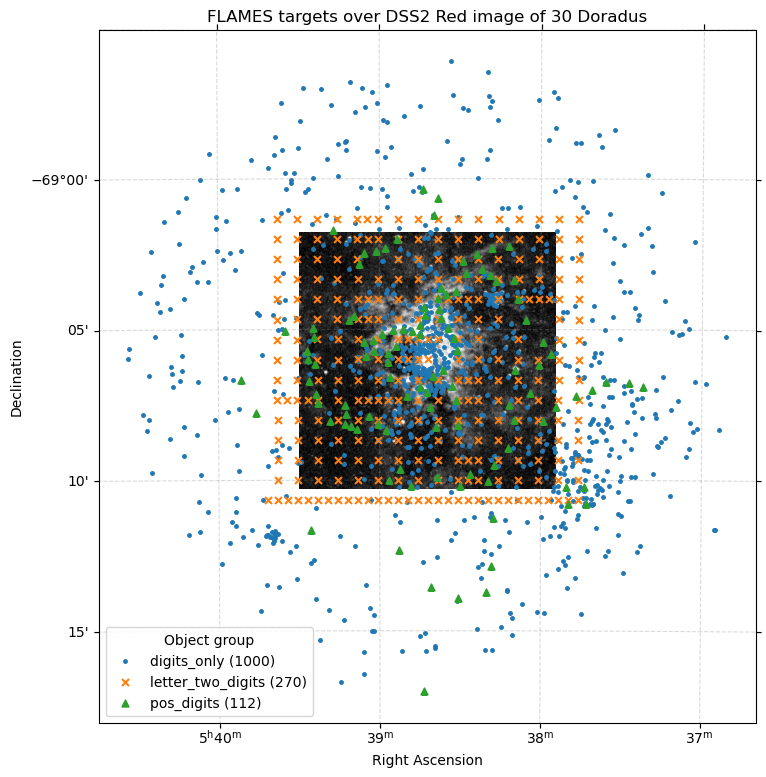

In [13]:
markers = {
    "digits_only": ".",
    "letter_two_digits": "x",
    "pos_digits": "^",
}

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(1, 1, 1, projection=wcs_bg)

ax.imshow(
    image_data,
    origin="lower",
    cmap="gray",
    vmin=np.nanpercentile(image_data, 1),
    vmax=np.nanpercentile(image_data, 99)
)

for group, df_group in df_flames.groupby("object_group"):
    ax.scatter(
        df_group["ra_deg"],
        df_group["dec_deg"],
        s=25,
        marker=markers.get(group, "o"),
        label=f"{group} ({len(df_group)})",
        transform=ax.get_transform("world")
    )

ax.set_title("FLAMES targets over DSS2 Red image of 30 Doradus")
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")
ax.legend(title="Object group")

plt.savefig("flames_30dor_positions_dss.png", dpi=300, bbox_inches="tight")


plt.show()

In [14]:
coord_cols = ["ra_deg", "dec_deg"]

# Boolean mask: True for rows whose RA/Dec pair is repeated
dup_mask = df_flames.duplicated(subset=coord_cols, keep=False)

# DataFrame with all repeated coordinate pairs
df_duplicates = df_flames.loc[dup_mask].sort_values(coord_cols)

print("Number of rows with repeated RA/Dec pairs:", dup_mask.sum())
print("Number of unique repeated coordinate pairs:")
print(df_duplicates[coord_cols].drop_duplicates().shape[0])

#df_duplicates

Number of rows with repeated RA/Dec pairs: 0
Number of unique repeated coordinate pairs:
0


# Creating subsamples

In [15]:
centro = SkyCoord(ra=c0.ra.deg*u.deg, dec=c0.dec.deg*u.deg, frame='icrs')

coords = SkyCoord(
    ra=df_flames["ra_deg"].values * u.deg,
    dec=df_flames["dec_deg"].values * u.deg,
    frame='icrs'
)

radio = 300 * u.arcsec   # por ejemplo
sep = coords.separation(centro)

df= df_flames[sep <= radio]

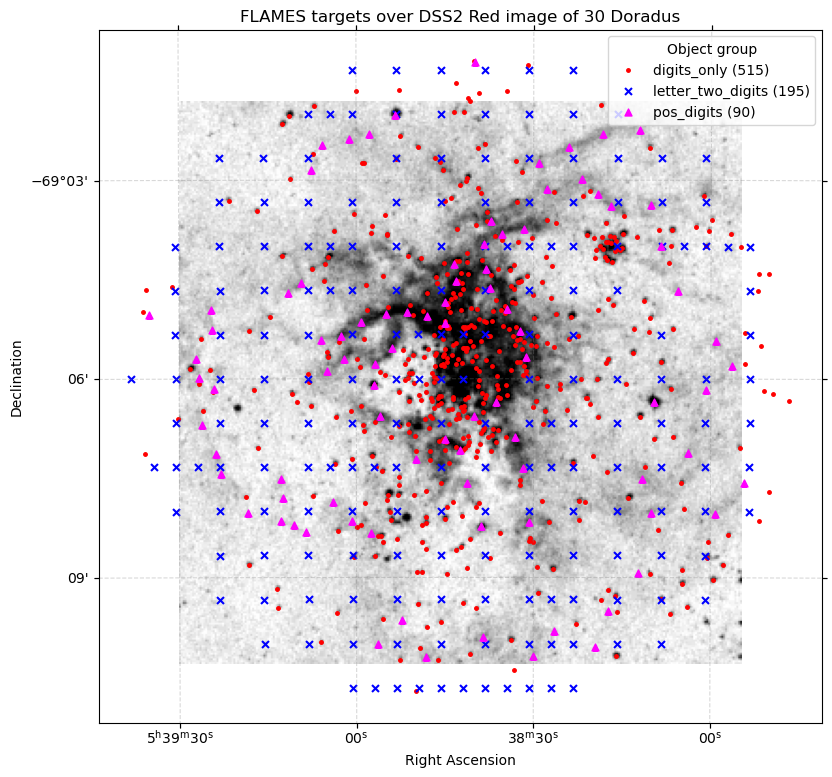

In [16]:
markers = {
    "digits_only": ".",
    "letter_two_digits": "x",
    "pos_digits": "^",
}

colors = {
    "digits_only": "red",
    "letter_two_digits": "blue",
    "pos_digits": "magenta",
}


fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(1, 1, 1, projection=wcs_bg)

ax.imshow(
    image_data,
    origin="lower",
    cmap="gray_r",
    vmin=np.nanpercentile(image_data, 1),
    vmax=np.nanpercentile(image_data, 99)
)

for group, df_group in df.groupby("object_group"):
    ax.scatter(
        df_group["ra_deg"],
        df_group["dec_deg"],
        s=25,
        marker=markers.get(group, "o"),
        color = colors.get(group, "o"),
        label=f"{group} ({len(df_group)})",
        transform=ax.get_transform("world")
    )

ax.set_title("FLAMES targets over DSS2 Red image of 30 Doradus")
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")
ax.legend(title="Object group")

#plt.savefig("flames_30dor_positions_dss_r300arcsec.png", dpi=300, bbox_inches="tight")

plt.show()

In [17]:
radius = 150 * u.arcsec   # por ejemplo
sep = coords.separation(centro)

df_sample = df_flames[sep <= radius]

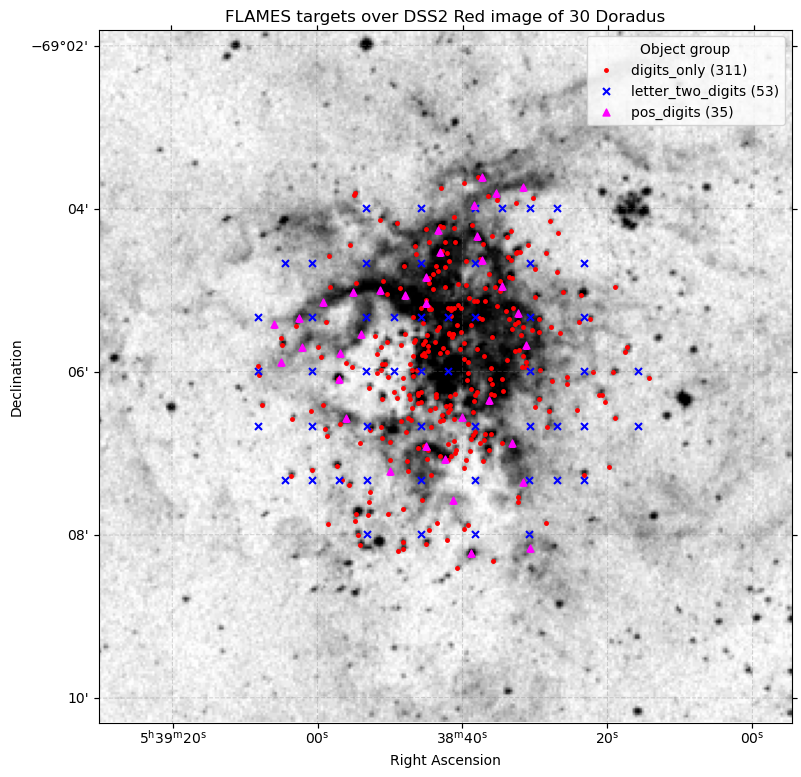

In [18]:
markers = {
    "digits_only": ".",
    "letter_two_digits": "x",
    "pos_digits": "^",
}

colors = {
    "digits_only": "red",
    "letter_two_digits": "blue",
    "pos_digits": "magenta",
}


fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(1, 1, 1, projection=wcs_bg)

ax.imshow(
    image_data,
    origin="lower",
    cmap="gray_r",
    vmin=np.nanpercentile(image_data, 1),
    vmax=np.nanpercentile(image_data, 99)
)

for group, df_group in df_sample.groupby("object_group"):
    ax.scatter(
        df_group["ra_deg"],
        df_group["dec_deg"],
        s=25,
        marker=markers.get(group, "o"),
        color = colors.get(group, "o"),
        label=f"{group} ({len(df_group)})",
        transform=ax.get_transform("world")
    )

ax.set_title("FLAMES targets over DSS2 Red image of 30 Doradus")
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")
ax.legend(title="Object group")

#plt.savefig("flames_30dor_positions_dss_r150arcsec.png", dpi=300, bbox_inches="tight")

plt.show()

In [19]:
# Output file
pickle_path = "df-flames-grid-r150arcsec.pkl"

# Save
with open(pickle_path, "wb") as f:
    pickle.dump(df_sample, f)

print(f"Saved pickle to:\n{pickle_path}")

Saved pickle to:
df-flames-grid-r150arcsec.pkl


In [20]:
coord_cols = ["ra_deg", "dec_deg"]

# Boolean mask: True for rows whose RA/Dec pair is repeated
dup_mask = df_sample.duplicated(subset=coord_cols, keep=False)

# DataFrame with all repeated coordinate pairs
df_duplicates = df_sample.loc[dup_mask].sort_values(coord_cols)

print("Number of rows with repeated RA/Dec pairs:", dup_mask.sum())
print("Number of unique repeated coordinate pairs:")
print(df_duplicates[coord_cols].drop_duplicates().shape[0])

#df_duplicates

Number of rows with repeated RA/Dec pairs: 0
Number of unique repeated coordinate pairs:
0


# Loading spectra

In [21]:
from spectra_utils import load_spectra_from_df

data_folder = 'ADP_FLAMES_30Dor_30arcmin'
fits_dir = Path(r"/Users/javier/FLAMES_30Dor")  / data_folder

spectra_dict = {}

for name, df in dfs_to_combine.items():
    print(f"\nLoading spectra for group {name}")
    spectra_dict[name] = load_spectra_from_df(df, fits_dir)


Loading spectra for group irr
Loaded 112 spectra

Loading spectra for group stellarA
Loaded 111 spectra

Loading spectra for group stellarB
Loaded 112 spectra

Loading spectra for group stellarD
Loaded 220 spectra

Loading spectra for group stellarE
Loaded 109 spectra

Loading spectra for group stellarG
Loaded 111 spectra

Loading spectra for group stellarI
Loaded 113 spectra

Loading spectra for group stellarJ
Loaded 113 spectra

Loading spectra for group stellarK
Loaded 111 spectra

Loading spectra for group letterW
Loaded 101 spectra

Loading spectra for group letterX
Loaded 98 spectra

Loading spectra for group letterY
Loaded 71 spectra


In [22]:
spectra_dict['letterW'][17]

{'filename': 'ADP.2019-01-31T23_53_43.019.fits',
 'object': 'u10',
 'ra_deg': 84.7839999999986,
 'dec_deg': -69.1555277777766,
 'wave': array([629.89733887, 629.90234375, 629.90734863, ..., 669.08721924,
        669.09222412, 669.09716797], shape=(7841,), dtype='>f8'),
 'flux': array([ 13.14996921, -18.11389732,  -8.57344723, ...,   7.33183006,
         10.09014039,  15.42239571], shape=(7841,), dtype='>f8'),
 'err': array([15.65980142, 21.79413795, 22.15235519, ...,  4.24901006,
         4.29882517,  4.35903651], shape=(7841,), dtype='>f8'),
 'snr': array([ 0.83972771, -0.83113621, -0.38702193, ...,  1.72553841,
         2.34718557,  3.53802857], shape=(7841,), dtype='>f8')}

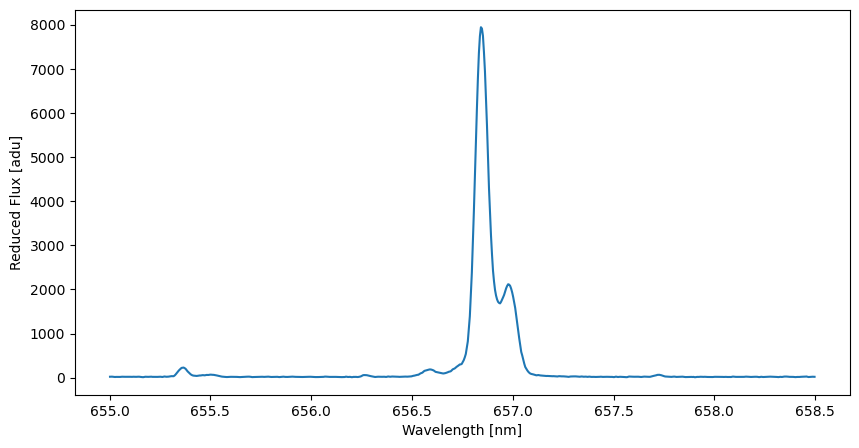

In [23]:
idx=10
sample = 'letterW'
wmin = 655.0
wmax = 658.5

mask = (spectra_dict[sample][idx]['wave'] >= wmin) & (spectra_dict[sample][idx]['wave'] <= wmax)

plt.figure(figsize=(10, 5))
plt.plot(spectra_dict[sample][idx]['wave'][mask], spectra_dict[sample][idx]['flux'][mask])
plt.xlabel("Wavelength [nm]")
plt.ylabel("Reduced Flux [adu]")
#plt.title(name_object)
plt.show()

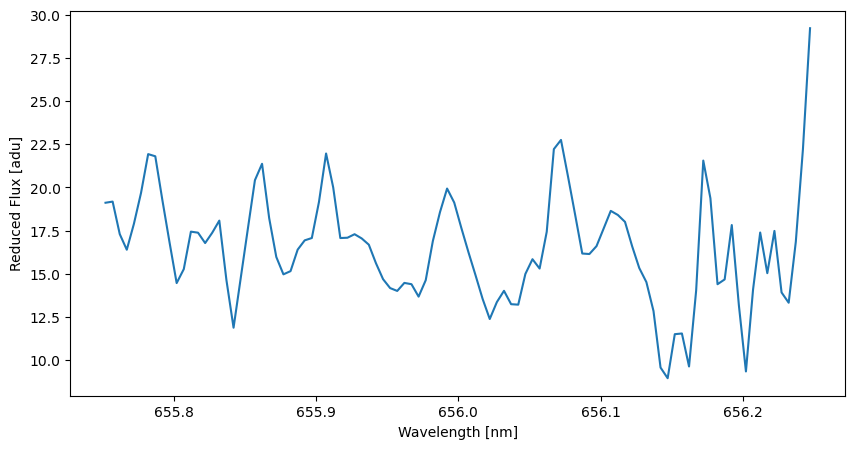

In [25]:
idx=10
sample = 'letterW'
wmin = 655.75
wmax = 656.25

mask = (spectra_dict[sample][idx]['wave'] >= wmin) & (spectra_dict[sample][idx]['wave'] <= wmax)

plt.figure(figsize=(10, 5))
plt.plot(spectra_dict[sample][idx]['wave'][mask], spectra_dict[sample][idx]['flux'][mask])
plt.xlabel("Wavelength [nm]")
plt.ylabel("Reduced Flux [adu]")
#plt.title(name_object)
plt.show()

In [28]:
spectra_dict[sample][idx]['flux'][mask].mean()

np.float64(16.493841083659408)